# Extracción, transformación y Carga de Datos del SECOP I y SECOP II

Este notebook contiene los pipeline para:
1. Extracción de los datos del SECOP I y II
2. Limpieza de las bases de datos
3. Integración de las bases de datos
4. Procesamiento
5. Carga en arhivos de datos para modelos analíticos

# Librerias

In [ ]:
# Instalar sodapy en modo silencioso
!pip install sodapy --quiet

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Cargar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sodapy import Socrata
from datetime import datetime
pd.set_option('display.max_columns', None)

In [ ]:
# Configurar conexion con google drive y con carpeta de google colab
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Colab Notebooks/Prediccion de Adiciones Proyectos de Infraestructura')

Mounted at /content/drive


# Funciones para las consultas

In [ ]:
def get_path(folder, file_path):
    """
    function to get the path of the file
    """
    current_directory = os.getcwd()
    return os.path.join(current_directory, folder, file_path)

In [ ]:
def get_query(folder, file_path):
    """
    function to get the query from a file
    """
    path = get_path(folder, file_path)
    # try to get the query
    with open(path, "r", encoding="utf8") as query_file:
        query = query_file.read()
    return query

In [ ]:
def parse_to_list(ls):
    """
    function to parse a list to a string
    """
    ids = [ str(i) for i in ls]
    ids = "'" + "','".join(ids) + "'"
    return ids

In [ ]:
def setClient(url='www.datos.gov.co', api_key='SOCRATA_APP_TOKEN', timeout=1000):
    """
    Set the client for the Socrata API
    """

    # Create client
    socrata_token = os.environ.get(api_key)

    client = Socrata(url,
                     socrata_token,
                     username=os.environ.get("SOCRATA_USERNAME"),
                     password=os.environ.get("SOCRATA_PASSWORD"),
                     timeout=timeout)
    return client

In [ ]:
def querySecop(query, id_data, client):
    """
    Extract data from the Socrata API
    """
    # Query data
    query_results = client.get(id_data, query=query)
    query_results = pd.DataFrame.from_dict(query_results)
    print("El numero de registros extraidos: {}".format(query_results.shape[0]))
    return query_results

In [ ]:
def getMetadata(id_data, client):
    """
    Extract metadata from the Socrata API
    """
    return client.get_metadata(id_data)

# Extracción SECOP I

In [ ]:
clientSECOP = setClient()

## Metadatos: Procesos SECOP I

In [ ]:
# Revisar metadaos
SECOPI_PROCESS_API = 'f789-7hwg'
metadaProcesosSECOPI = getMetadata(id_data=SECOPI_PROCESS_API, client=clientSECOP)
[x['name'] + ": " + x['fieldName'] for x in metadaProcesosSECOPI['columns']]

['UID: uid',
 'Anno Cargue SECOP: anno_cargue_secop',
 'Anno Firma Contrato: anno_firma_contrato',
 'Nivel Entidad: nivel_entidad',
 'Orden Entidad: orden_entidad',
 'Nombre Entidad: nombre_entidad',
 'NIT de la Entidad: nit_de_la_entidad',
 'Código de la Entidad: c_digo_de_la_entidad',
 'ID Modalidad: id_modalidad',
 'Modalidad de Contratacion: modalidad_de_contratacion',
 'Estado del Proceso: estado_del_proceso',
 'Causal de Otras formas de Contratacion Directa: causal_de_otras_formas_de',
 'ID Regimen de Contratacion: id_regimen_de_contratacion',
 'Nombre Regimen de Contratacion: nombre_regimen_de_contratacion',
 'ID Objeto a Contratar: id_objeto_a_contratar',
 'Objeto a Contratar: objeto_a_contratar',
 'Detalle del Objeto a Contratar: detalle_del_objeto_a_contratar',
 'Tipo De Contrato: tipo_de_contrato',
 'Municipio de Obtencion: municipio_de_obtencion',
 'Municipio de Entrega: municipio_de_entrega',
 'Municipios Ejecucion: municipios_ejecucion',
 'Fecha de Cargue en el SECOP: fec

In [ ]:
# Consultar un campo en especifico
meta_amount = [x for x in metadaProcesosSECOPI['columns'] if x['name'] == 'Modalidad de Contratacion'][0]
meta_amount

{'id': 598661861,
 'name': 'Modalidad de Contratacion',
 'dataTypeName': 'text',
 'description': 'Modalidad de selección que se determinó para el proceso de compra actual, Ej: Licitación Pública, Contratación Directa.',
 'fieldName': 'modalidad_de_contratacion',
 'position': 10,
 'renderTypeName': 'text',
 'tableColumnId': 141655715,
 'format': {}}

In [ ]:
results = clientSECOP.get(SECOPI_PROCESS_API,
                        select="anno_firma_contrato, count(*) as total",
                        group="anno_firma_contrato",
                        order="total DESC")
pd.DataFrame.from_dict(results)

,anno_firma_contrato,total
0,Sin Firma,1221772
1,2017,1177758
2,2019,1142543
3,2016,1070186
4,2018,1050366
5,2020,921573
6,2015,907152
7,2021,904942
8,2014,776365
9,2013,607359


## Query: Procesos SECOP I

In [ ]:
queryPath = get_path('', 'querySECOPIProcesos.sql')
queryBase = get_query('', queryPath)
#print(querySECOPI)
procesosSECOPI = querySecop(queryBase, client=clientSECOP, id_data=SECOPI_PROCESS_API)

El numero de contratos extraidos: 29183


In [ ]:
procesosSECOPI.shape

(29183, 32)

In [ ]:
procesosSECOPI.to_csv('procesosSECOPI.csv', index=False)

In [ ]:
procesosSECOPI = pd.read_csv('procesosSECOPI.csv')

In [ ]:
procesosSECOPI.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29183 entries, 0 to 29182
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   uid                             29183 non-null  object
 1   nombre_de_la_entidad            29183 non-null  object
 2   nit_de_la_entidad               29183 non-null  object
 3   departamento_entidad            29183 non-null  object
 4   clasificacion_entidad           29183 non-null  object
 5   orden                           29183 non-null  object
 6   modalidad                       29183 non-null  object
 7   tipo_contrato                   29183 non-null  object
 8   causal_contratacion_directa     29183 non-null  object
 9   objeto_a_contratar              29183 non-null  object
 10  detalle_objeto                  29183 non-null  object
 11  cuantia_proceso                 29183 non-null  int64 
 12  cuantia_contrato                29183 non-null

## Convertir las columnas tipo fecha

In [ ]:
procesosSECOPI['fecha_firma'] = pd.to_datetime(procesosSECOPI['fecha_firma'])
procesosSECOPI['fecha_ini_ejec_contrato'] = pd.to_datetime(procesosSECOPI['fecha_ini_ejec_contrato'])
procesosSECOPI['fecha_fin_ejec_contrato'] = pd.to_datetime(procesosSECOPI['fecha_fin_ejec_contrato'])

In [ ]:
procesosSECOPI[['fecha_firma', 'fecha_ini_ejec_contrato', 'fecha_fin_ejec_contrato']]

,fecha_firma,fecha_ini_ejec_contrato,fecha_fin_ejec_contrato
0,2015-10-26,2015-11-10,2016-03-10
1,2019-11-14,2019-12-12,2020-03-11
2,2014-10-17,2014-10-17,2014-12-01
3,2015-06-03,2015-06-04,2015-10-04
4,2018-01-03,2018-01-03,2019-01-03
...,...,...,...
29178,2017-03-08,2017-03-08,2017-05-08
29179,2022-07-16,2022-07-26,2022-11-26
29180,2018-07-13,2018-08-22,2018-12-05
29181,2019-10-31,2019-12-02,2020-01-29


In [ ]:
procesosSECOPI['anno_firma'] = procesosSECOPI['fecha_firma'].dt.year

## Creación de la columna es grupo

In [ ]:
procesosSECOPI['es_grupo'] = procesosSECOPI['nom_razon_social_contratista'].str.upper().str.contains('CONSORCIO|CONSORSIO|UNION TEMPORAL|CONSORCIOS|UNIÓN TEMPORAL')

In [ ]:
procesosSECOPI['es_grupo'].mean()

0.35486413322824933

## Orden y Nivel de Entidad

In [ ]:
results = clientSECOP.get(SECOPI_PROCESS_API,
                        select="nivel_entidad, count(*) as total",
                        group="nivel_entidad",
                        order="total DESC")
pd.DataFrame.from_dict(results)

,nivel_entidad,total
0,TERRITORIAL,10022013
1,NACIONAL,1902513
2,No Definido,27246


In [ ]:
results = clientSECOP.get(SECOPI_PROCESS_API,
                        select="orden_entidad, count(*) as total",
                        group="orden_entidad",
                        order="total DESC")
pd.DataFrame.from_dict(results)

,orden_entidad,total
0,TERRITORIAL DEPARTAMENTAL DESCENTRALIZADO,3168313
1,TERRITORIAL DISTRITAL MUNICIPAL NIVEL 6,2788226
2,NACIONAL DESCENTRALIZADO,1120956
3,TERRITORIAL DISTRITAL MUNICIPAL NIVEL 2,983235
4,TERRITORIAL DEPARTAMENTAL CENTRALIZADO,910681
5,NACIONAL CENTRALIZADO,872317
6,TERRITORIAL DISTRITAL MUNICIPAL NIVEL 1,764149
7,DISTRITO CAPITAL,511309
8,TERRITORIAL DISTRITAL MUNICIPAL NIVEL 5,330383
9,TERRITORIAL DISTRITAL MUNICIPAL NIVEL 4,310012


In [ ]:
procesosSECOPI['orden'].value_counts()

orden
TERRITORIAL    26563
NACIONAL        2617
NO DEFINIDO        3
Name: count, dtype: int64

In [ ]:
procesosSECOPI.rename(columns={'orden': 'orden_entidad'}, inplace=True)

In [ ]:
procesosSECOPI['clasificacion_entidad'].value_counts()

clasificacion_entidad
TERRITORIAL DISTRITAL MUNICIPAL NIVEL 6      14089
TERRITORIAL DEPARTAMENTAL DESCENTRALIZADO     3346
TERRITORIAL DISTRITAL MUNICIPAL NIVEL 2       1926
TERRITORIAL DISTRITAL MUNICIPAL NIVEL 1       1780
TERRITORIAL DEPARTAMENTAL CENTRALIZADO        1658
TERRITORIAL DISTRITAL MUNICIPAL NIVEL 4       1640
TERRITORIAL DISTRITAL MUNICIPAL NIVEL 5       1474
NACIONAL DESCENTRALIZADO                      1465
NACIONAL CENTRALIZADO                         1150
TERRITORIAL DISTRITAL MUNICIPAL NIVEL 3        461
DISTRITO CAPITAL                               191
No Definido                                      3
Name: count, dtype: int64

# Extracción SECOP II

## Consulta contratos SECOP II

In [ ]:
SECOPII_CONTRATOS_API = 'jbjy-vk9h'
metadaContratosSECOPII = getMetadata(id_data=SECOPII_CONTRATOS_API, client=clientSECOP)
[x['name'] + ": " + x['fieldName'] for x in metadaContratosSECOPII['columns']]

['Nombre Entidad: nombre_entidad',
 'Nit Entidad: nit_entidad',
 'Departamento: departamento',
 'Ciudad: ciudad',
 'Localización: localizaci_n',
 'Orden: orden',
 'Sector: sector',
 'Rama: rama',
 'Entidad Centralizada: entidad_centralizada',
 'Proceso de Compra: proceso_de_compra',
 'ID Contrato: id_contrato',
 'Referencia del Contrato: referencia_del_contrato',
 'Estado Contrato: estado_contrato',
 'Codigo de Categoria Principal: codigo_de_categoria_principal',
 'Descripcion del Proceso: descripcion_del_proceso',
 'Tipo de Contrato: tipo_de_contrato',
 'Modalidad de Contratacion: modalidad_de_contratacion',
 'Justificacion Modalidad de Contratacion: justificacion_modalidad_de',
 'Fecha de Firma: fecha_de_firma',
 'Fecha de Inicio del Contrato: fecha_de_inicio_del_contrato',
 'Fecha de Fin del Contrato: fecha_de_fin_del_contrato',
 'Fecha de Inicio de Ejecucion: fecha_de_inicio_de_ejecucion',
 'Fecha de Fin de Ejecucion: fecha_de_fin_de_ejecucion',
 'Condiciones de Entrega: condicione

In [ ]:
SECOPII_CONTRATOS_API = 'jbjy-vk9h'
queryPath = get_path('', 'querySECOPIIContratos.sql')
queryBase = get_query('', queryPath)
#print(querySECOPI)
contratosSECOPII = querySecop(queryBase, id_data=SECOPII_CONTRATOS_API, client=clientSECOP)

El numero de contratos extraidos: 2772


In [ ]:
contratosSECOPII.to_csv('contratosSECOPII.csv', index=False)

In [ ]:
contratosSECOPII = pd.read_csv('contratosSECOPII.csv')

In [ ]:
contratosSECOPII.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   uid                             2772 non-null   object
 1   id_proceso                      2772 non-null   object
 2   nombre_de_la_entidad            2772 non-null   object
 3   nit_de_la_entidad               2772 non-null   int64 
 4   departamento_entidad            2772 non-null   object
 5   orden_entidad_SECOPII           2772 non-null   object
 6   entidad_centralizada_SECOPII    2772 non-null   object
 7   modalidad                       2772 non-null   object
 8   tipo_contrato                   2772 non-null   object
 9   justificacion_modalidad         2772 non-null   object
 10  detalle_objeto                  2772 non-null   object
 11  valor_contrato_con_adiciones    2772 non-null   int64 
 12  fecha_firma                     2772 non-null   

In [ ]:
contratosSECOPII['fecha_firma'] = pd.to_datetime(contratosSECOPII['fecha_firma'])
contratosSECOPII['fecha_ini_ejec_contrato'] = pd.to_datetime(contratosSECOPII['fecha_ini_ejec_contrato'])
contratosSECOPII['fecha_fin_ejec_contrato'] = pd.to_datetime(contratosSECOPII['fecha_fin_ejec_contrato'])

In [ ]:
contratosSECOPII[['fecha_firma', 'fecha_ini_ejec_contrato', 'fecha_fin_ejec_contrato']]

,fecha_firma,fecha_ini_ejec_contrato,fecha_fin_ejec_contrato
0,2023-11-27,2023-11-30,2023-12-30
1,2019-10-03,2018-09-19,2018-11-16
2,2019-09-16,2019-09-16,2019-12-15
3,2022-09-02,2022-09-22,2023-02-25
4,2023-06-28,2023-07-26,2023-09-23
...,...,...,...
2767,2019-12-04,2019-12-12,2021-05-14
2768,2021-12-03,2021-12-09,2021-12-31
2769,2023-08-30,2023-09-07,2023-12-06
2770,2023-08-29,2023-09-01,2024-04-30


## Unificar Columnas con la de procesos SECOP I

**Variables a Incluir:**
- anno_firma (Listo)
- cuantia_contrato: Filtrar procesos de contrato únicopara establecer valor de contrato con mayor exactitud. Por ahora no consideramos los procesos de múltiples contratos.
- cuantia_proceso: Buscar en base de procesos
- rango_de_ejec_del_contrato: buscar en base de procesos
- tiempo_adiciones_en_meses: colocar cero
- valor_total_de_adiciones: crear como la diferencia entre el valor total con adiciones y el precio base.

**Variables a excluir de SECOP I:**
- causal_contratacion_directa
- id_adjudicacion
- objeto_a_contratar

**Orden y nivel de entidad**
- Estandarizar para que Orden: Nacional o Territorial
- Descentralizada

In [ ]:
set(procesosSECOPI.columns) - set(contratosSECOPII.columns)

{'anno_firma',
 'causal_contratacion_directa',
 'clasificacion_entidad',
 'cuantia_contrato',
 'cuantia_proceso',
 'dpto_y_muni_contratista',
 'id_adjudicacion',
 'objeto_a_contratar',
 'orden_entidad',
 'rango_de_ejec_del_contrato',
 'tiempo_adiciones_en_meses',
 'valor_total_de_adiciones'}

### Año de Firma

In [ ]:
# crear un campo con el año de la fecha de firma
contratosSECOPII['anno_firma'] = contratosSECOPII['fecha_firma'].dt.year
# resumir por año
contratosSECOPII.groupby('anno_firma').size()

anno_firma
2017     12
2018     74
2019    247
2020    282
2021    599
2022    727
2023    726
2024    105
dtype: int64

### Cuantia de contrato, procesos y adiciones

In [ ]:
# Identificar procesos de un solo contrato
contratoPorProceso = contratosSECOPII['id_proceso'].value_counts().reset_index(name='num_contratos')
contratoPorProceso

,id_proceso,num_contratos
0,CO1.BDOS.888401,87
1,CO1.BDOS.1388456,36
2,CO1.BDOS.3467337,29
3,CO1.BDOS.4424050,29
4,CO1.BDOS.3239175,24
...,...,...
2154,CO1.BDOS.2203595,1
2155,CO1.BDOS.3145938,1
2156,CO1.BDOS.2000158,1
2157,CO1.BDOS.3392427,1


In [ ]:
SECOPII_PROCESOS_API = 'p6dx-8zbt'

results = clientSECOP.get(SECOPII_PROCESOS_API,
                        select="*",
                        where="tipo_de_contrato = 'Obra' AND estado_resumen = 'Adjudicado'",
                        #group="anno_firma_contrato",
                        #order="total DESC"
                        limit=100)

In [ ]:
temp1 = pd.DataFrame.from_dict(results)
temp1.head()

,entidad,nit_entidad,departamento_entidad,ciudad_entidad,ordenentidad,codigo_pci,id_del_proceso,referencia_del_proceso,ppi,id_del_portafolio,nombre_del_procedimiento,descripci_n_del_procedimiento,fase,fecha_de_publicacion_del,fecha_de_ultima_publicaci,fecha_de_publicacion_fase_3,precio_base,modalidad_de_contratacion,justificaci_n_modalidad_de,duracion,unidad_de_duracion,fecha_de_recepcion_de,fecha_de_apertura_de_respuesta,fecha_de_apertura_efectiva,ciudad_de_la_unidad_de,nombre_de_la_unidad_de,proveedores_invitados,proveedores_con_invitacion,visualizaciones_del,proveedores_que_manifestaron,respuestas_al_procedimiento,respuestas_externas,conteo_de_respuestas_a_ofertas,proveedores_unicos_con,numero_de_lotes,estado_del_procedimiento,id_estado_del_procedimiento,adjudicado,id_adjudicacion,codigoproveedor,departamento_proveedor,ciudad_proveedor,fecha_adjudicacion,valor_total_adjudicacion,nombre_del_adjudicador,nombre_del_proveedor,nit_del_proveedor_adjudicado,codigo_principal_de_categoria,estado_de_apertura_del_proceso,tipo_de_contrato,subtipo_de_contrato,categorias_adicionales,urlproceso,codigo_entidad,estado_resumen
0,INVIAS,800215807,Distrito Capital de Bogotá,Bogotá,Nacional,Centralizada,CO1.REQ.976985,LP-DT-CAU-003-2019_3 (Fase de Selección (Prese...,700676059,CO1.BDOS.927424,MANTENIMIENTO RUTINARIO; DE VIAS A CARGO DEL I...,"MANTENIMIENTO RUTINARIO, DE VIAS A CARGO DEL I...",Fase de Selección (Presentación de ofertas),2019-09-30T00:00:00.000,2019-09-30T00:00:00.000,2019-09-30T00:00:00.000,53520784298,Licitación pública Obra Publica,No Defenido,33,Mes(es),2019-10-11T00:00:00.000,2019-11-26T00:00:00.000,2019-11-26T00:00:00.000,Cali,Dirección Territorial Cauca,0,0,107,0,51,0,0,51,38,Seleccionado,70,Si,CO1.AWD.616637,704527936,Cauca,Bolívar,2022-07-08T00:00:00.000,1217527123,JORGE ALONSO ORTEGA ROJAS,COOPERATIVA DE TRABAJO ASOCIADO SIGLO XXI,817002635,V1.72141000,Cerrado,Obra,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,700676059,Adjudicado
1,INVIAS,800215807,Distrito Capital de Bogotá,Bogotá,Nacional,Centralizada,CO1.REQ.810103,LP-DT-CAS-001-2019 (Fase de Selección (Present...,700676059,CO1.BDOS.758519,MANTENIMIENTO RUTINARIO VÍAS A CARGO DEL INSTI...,MANTENIMIENTO RUTINARIO VÍAS A CARGO DEL INSTI...,Fase de Selección (Presentación de ofertas),2019-03-12T00:00:00.000,2019-03-12T00:00:00.000,2019-03-12T00:00:00.000,3225297489,Licitación pública Obra Publica,No Defenido,6,Mes(es),2019-03-22T00:00:00.000,2019-05-02T00:00:00.000,2019-05-02T00:00:00.000,No Aplica,Dirección Territorial Casanare,0,0,74,0,12,0,0,12,14,Seleccionado,70,Si,CO1.AWD.482114,706196763,Casanare,Pore,2019-05-15T00:00:00.000,210178584,Manuel Francisco Ballesteros Salcedo,Cooperativa de trabajo asociado Nuevo Horizont...,844005123,V1.72141000,Cerrado,Obra,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,700676059,Adjudicado
2,INVIAS,800215807,Distrito Capital de Bogotá,Bogotá,Nacional,Centralizada,CO1.REQ.810103,LP-DT-CAS-001-2019 (Fase de Selección (Present...,700676059,CO1.BDOS.758519,MANTENIMIENTO RUTINARIO VÍAS A CARGO DEL INSTI...,MANTENIMIENTO RUTINARIO VÍAS A CARGO DEL INSTI...,Fase de Selección (Presentación de ofertas),2019-03-12T00:00:00.000,2019-03-12T00:00:00.000,2019-03-12T00:00:00.000,3225297489,Licitación pública Obra Publica,No Defenido,6,Mes(es),2019-03-22T00:00:00.000,2019-05-02T00:00:00.000,2019-05-02T00:00:00.000,No Aplica,Dirección Territorial Casanare,0,0,74,0,12,0,0,12,14,Seleccionado,70,Si,CO1.AWD.482114,706196763,Casanare,Pore,2019-05-15T00:00:00.000,210178584,Manuel Francisco Ballesteros Salcedo,Cooperativa de trabajo asociado Nuevo Horizont...,844005123,V1.72141000,Cerrado,Obra,No Definido,No definido,{'url': 'https://community.secop.gov.co/Public...,700676059,Adjudicado
3,INVIAS,800215807,Distrito Capital de Bogotá,Bogotá,Nacional,Centralizada,CO1.REQ.810103,LP-DT-CAS-001-2019 (Fase de Selección (Present...,700676059,CO1.BDOS.758519,MANTENIMIENTO RUTINARIO VÍAS A CARGO DEL INSTI...,MA

In [ ]:
temp1[['valor_total_adjudicacion','precio_base']]

,valor_total_adjudicacion,precio_base
0,1217527123,53520784298
1,210178584,3225297489
2,210178584,3225297489
3,210178584,3225297489
4,176901693,3068298442
...,...,...
95,0,0
96,0,0
97,0,0
98,0,0


In [ ]:
# Parametros iniciales para la consulta
idDataAPI = SECOPII_PROCESOS_API
ids = list(contratoPorProceso[contratoPorProceso['num_contratos'] <= 1]['id_proceso'])
sqlFile = 'querySECOPIIProcesos.sql'

# Cortes de busqueda
cortesIndex = [i for i in np.arange(0, len(ids), 500)]
if max(cortesIndex) < len(ids):
    cortesIndex.append(len(ids))

# Consulta
for i in range(len(cortesIndex) - 1):
    print("Busqueda de {} - {}".format(cortesIndex[i], cortesIndex[i + 1]))
    tempids = ids[cortesIndex[i]:cortesIndex[i + 1]]
    tempids = parse_to_list(tempids)
    if i == 0:
        querySECOP = get_query('', sqlFile)
        querySECOP = querySECOP.format(list_id_proceso=tempids)
        dfSECOP = querySecop(querySECOP, id_data=idDataAPI, client=clientSECOP)
    else:
        querySECOP = get_query('', sqlFile)
        querySECOP = querySECOP.format(list_id_proceso=tempids)
        dfSECOP = pd.concat([dfSECOP, querySecop(querySECOP, id_data=idDataAPI, client=clientSECOP)])

Busqueda de 0 - 500


El numero de contratos extraidos: 512
Busqueda de 500 - 1000
El numero de contratos extraidos: 536
Busqueda de 1000 - 1500
El numero de contratos extraidos: 565
Busqueda de 1500 - 2000
El numero de contratos extraidos: 514
Busqueda de 2000 - 2023
El numero de contratos extraidos: 26


In [ ]:
dfSECOP.to_excel('procesosSECOPII.xlsx', index=False)
dfSECOP.to_csv('procesosSECOPII.csv', index=False)

In [ ]:
procesosSECOPII = pd.read_csv('procesosSECOPII.csv')

In [ ]:
procesosCount = procesosSECOPII.drop_duplicates()['id_proceso'].value_counts().reset_index(name='total')
procesosCount

,id_proceso,total
0,CO1.BDOS.1923341,40
1,CO1.BDOS.2033003,25
2,CO1.BDOS.1810896,20
3,CO1.BDOS.2232623,12
4,CO1.BDOS.468933,8
...,...,...
1808,CO1.BDOS.2886013,1
1809,CO1.BDOS.2884807,1
1810,CO1.BDOS.2883214,1
1811,CO1.BDOS.2882405,1


In [ ]:
listProcesosUnicos = list(procesosCount[procesosCount['total'] == 1]['id_proceso'])

In [ ]:
selProcesosSECOPII = procesosSECOPII[procesosSECOPII['id_proceso'].isin(listProcesosUnicos)]

In [ ]:
# join entre los contratos y los procesos
contratosSECOPII = contratosSECOPII.merge(selProcesosSECOPII, on='id_proceso', how='inner')
contratosSECOPII

,uid,id_proceso,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,orden_entidad_SECOPII,entidad_centralizada_SECOPII,modalidad,tipo_contrato,justificacion_modalidad,detalle_objeto,valor_contrato_con_adiciones,fecha_firma,fecha_ini_ejec_contrato,plazo_de_ejec_del_contrato_x,tiempo_adiciones_en_dias,fecha_fin_ejec_contrato,urlproceso,identificacion_del_contratista,es_grupo,es_pyme,espostconflicto,codigo_proveedor,municipio_entidad,nom_razon_social_contratista,estado_del_proceso,anno_firma,cuantia_proceso,cuantia_contrato,plazo_de_ejec_del_contrato_y,rango_de_ejec_del_contrato_y,departamento_proveedor,ciudad_proveedor,id_adjudicacion,fecha_adjudicacion,adjudicado,estado_resumen
0,CO1.PCCNTR.5582573,CO1.BDOS.5069635,SENA REGIONAL GUAJIRA Grupo Mixto de Apoyo Adm...,899999034,La Guajira,Nacional,Descentralizada,Selección Abreviada de Menor Cuantía,OBRA,Presupuesto menor al 10% de la Menor Cuantía,ADECUACIÓN Y REMODELACIÓN DE ESPACIOS PARA PUN...,570872051,2023-11-27,2023-11-30,30 Dia(s),0,2023-12-30,{'url': 'https://community.secop.gov.co/Public...,No Definido,Si,No,No,723794202,Riohacha,CONSORCIO GUAJIRA,TERMINADO,2023,575852191,570872051,30,día(s),No Definido,Bogotá,CO1.AWD.1771885,2023-11-22T00:00:00.000,Si,Adjudicado
1,CO1.PCCNTR.539999,CO1.BDOS.462373,MUNICIPIO DE HONDA,800100058,Tolima,Territorial,Centralizada,Selección Abreviada de Menor Cuantía,OBRA,Presupuesto menor al 10% de la Menor Cuantía,OBRA CIVIL PARA LA PAVIMENTACION DE LA CARRERA...,252937734,2019-10-03,2018-09-19,Dia(s),0,2018-11-16,{'url': 'https://community.secop.gov.co/Public...,No Definido,Si,Si,No,704909589,Honda,CONSORCIO INFRAESTRUCTURAS 2018,TERMINADO,2019,217769000,217736210,2,Mes(es),No Definido,Ibagué,CO1.AWD.340443,2018-08-27T00:00:00.000,Si,Adjudicado
2,CO1.PCCNTR.1095329,CO1.BDOS.897231,GOBERNACION DE CALDAS - Primero la Gente,890801052,Caldas,Territorial,Centralizada,Selección Abreviada de Menor Cuantía,OBRA,Presupuesto menor al 10% de la Menor Cuantía,ADECUACIONES MENORES PARA GARANTIZAR LA OPERAT...,98595810,2019-09-16,2019-09-16,Dia(s),0,2019-12-15,{'url': 'https://community.secop.gov.co/Public...,800250918,No,Si,No,702957408,No Definido,ACUAMEUNIERSAS,TERMINADO,2019,99676915,98595810,3,Mes(es),Distrito Capital de Bogotá,No Definido,CO1.AWD.581614,2019-09-10T00:00:00.000,Si,Adjudicado
3,CO1.PCCNTR.3959080,CO1.BDOS.2949067,ALCALDIA MUNICIPAL DE RESTREPO META,800098199,Meta,Territorial,Centralizada,Licitación pública Obra Publica,OBRA,Article30_1993,MEJORAMIENTO DE LA VÍA QUE CONDUCE AL INTERNAD...,471315124,2022-09-02,2022-09-22,4 Mes(es),0,2023-02-25,{'url': 'https://community.secop.gov.co/Public...,901629203,Si,Si,No,717994032,Restrepo,CONSORCIO ESFUERZO VERTICAL PLV,TERMINADO,2022,488303830,471315124,3,Mes(es),No Definido,Chía,CO1.AWD.1380033,2022-08-26T00:00:00.000,Si,Adjudicado
4,CO1.PCCNTR.2510789,CO1.BDOS.1941934,MUNICIPIO DE TUNJA/,891800846,Boyacá,Territorial,Centralizada,Mínima cuantía,OBRA,Presupuesto inferior al 10% de la menor cuantía,SI-100 - ADECUACIÓN DEL TERRENO PARA LA CONSTR...,55602870,2021-05-14,2021-07-27,40 Dia(s),0,2021-09-03,{'url': 'https://community.secop.gov.co/Public...,7183019,No,Si,No,713145092,Tunja,EDWIN FERNANDO RIVERA OROZCO,TERMINADO,2021,40070955,37104704,40,día(s),Boyacá,Tunja,CO1.AWD.1012341,2021-05-13T00:00:00.000,Si,Adjudicado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1805,CO1.PCCNTR.1201116,CO1.BDOS.939907,FUNDACION GILBERTO ALZATE AVENDAÑO,860044113,Distrito Capital de Bogotá,Territorial,Centralizada,Licitación pública Obra Publica,OBRA,Article30_1993,CONTRATAR POR EL SISTEMA DE PRECIOS UNITARIOS ...,1869704425,2019-12-04,2019-12-12,Dia(s),0,2021-05-14,{'url': 'https://community.secop.gov.co/Public...,800060428,No,Si,No,701427403,No Definido,OBRACIC SAS,TERMINADO,2019,1878989690,1839599824,9,Mes(es),Distrito Capital de Bogotá,No Definido,CO1.AWD.629307,2019-11-27T00:00:00.000,Si,Adjudic

In [ ]:
# Calcular la diferencia porcentual entre el valor total de adjudicacion y el precio base y guardalo en un array
contratosSECOPII['diferencia_porcentual'] = (contratosSECOPII['cuantia_contrato'] - contratosSECOPII['cuantia_proceso']) / contratosSECOPII['cuantia_proceso']


In [ ]:
contratosSECOPII['diferencia_porcentual'].describe()

count    1810.000000
mean        1.065251
std        33.198342
min        -0.999000
25%        -0.040948
50%        -0.014386
75%        -0.000409
max       999.000000
Name: diferencia_porcentual, dtype: float64

In [ ]:
# Calcular el total de adiciones
contratosSECOPII['valor_total_de_adiciones'] = contratosSECOPII['valor_contrato_con_adiciones'] - contratosSECOPII['cuantia_contrato']

In [ ]:
# columna que indica si el contrato tiene adiciones
contratosSECOPII['tiene_adiciones'] = contratosSECOPII['valor_total_de_adiciones'] > 0

In [ ]:
# Calcular el porcentaje de contratos con adiciones
contratosSECOPII['tiene_adiciones'].mean()

0.44751381215469616

In [ ]:
# Calcula el porcentaje de la adición de cada contrato
contratosSECOPII['porcentaje_adicion'] = contratosSECOPII['valor_total_de_adiciones'] / contratosSECOPII['cuantia_contrato']

In [ ]:
contratosSECOPII['porcentaje_adicion'].describe()

count    1810.000000
mean        0.131517
std         0.314464
min        -0.575244
25%         0.000000
50%         0.000000
75%         0.235492
max        10.644181
Name: porcentaje_adicion, dtype: float64

<Axes: ylabel='Frequency'>

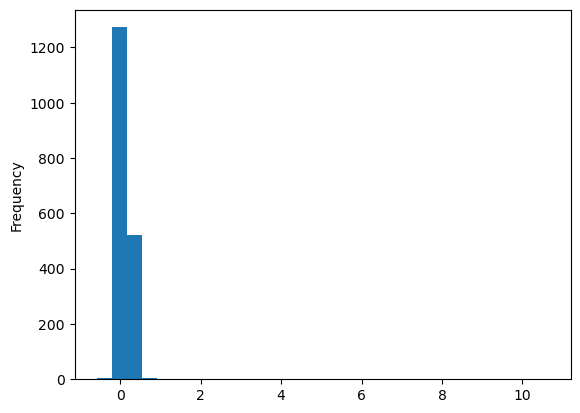

In [ ]:
contratosSECOPII['porcentaje_adicion'].plot(kind='hist', bins=30)

### Duración del contrato

In [ ]:
# Supongamos que df es tu DataFrame
# Usamos una expresión regular para separar el número y la unidad de tiempo
contratosSECOPII[['plazo_de_ejec_del_contrato', 'rango_de_ejec_del_contrato']] = contratosSECOPII['plazo_de_ejec_del_contrato_x'].str.extract(r'(\d+)\s*(\w+\(.*\))')

# Convertir la columna 'plazo' a tipo numérico
contratosSECOPII['plazo_de_ejec_del_contrato'] = pd.to_numeric(contratosSECOPII['plazo_de_ejec_del_contrato'])

# Mostrar el resultado
contratosSECOPII[contratosSECOPII['rango_de_ejec_del_contrato'].isnull()][['plazo_de_ejec_del_contrato_x','plazo_de_ejec_del_contrato_y','rango_de_ejec_del_contrato_y','plazo_de_ejec_del_contrato', 'rango_de_ejec_del_contrato']]

,plazo_de_ejec_del_contrato_x,plazo_de_ejec_del_contrato_y,rango_de_ejec_del_contrato_y,plazo_de_ejec_del_contrato,rango_de_ejec_del_contrato
1,Dia(s),2,Mes(es),NaN,NaN
2,Dia(s),3,Mes(es),NaN,NaN
33,Dia(s),0,día(s),NaN,NaN
41,Dia(s),2,Mes(es),NaN,NaN
48,No definido,3,Mes(es),NaN,NaN
...,...,...,...,...,...
1786,Dia(s),75,día(s),NaN,NaN
1791,Dia(s),3,Mes(es),NaN,NaN
1793,Dia(s),10,Mes(es),NaN,NaN
1802,Dia(s),6,Mes(es),NaN,NaN


In [ ]:
contratosSECOPII.loc[contratosSECOPII['rango_de_ejec_del_contrato'].isnull(), 'rango_de_ejec_del_contrato'] = contratosSECOPII.loc[contratosSECOPII['rango_de_ejec_del_contrato'].isnull(), 'rango_de_ejec_del_contrato_y']
contratosSECOPII.loc[contratosSECOPII['plazo_de_ejec_del_contrato'].isnull(), 'plazo_de_ejec_del_contrato'] = contratosSECOPII.loc[contratosSECOPII['plazo_de_ejec_del_contrato'].isnull(), 'plazo_de_ejec_del_contrato_y']

In [ ]:
contratosSECOPII[contratosSECOPII['rango_de_ejec_del_contrato'].isnull()][['plazo_de_ejec_del_contrato_x','plazo_de_ejec_del_contrato_y','rango_de_ejec_del_contrato_y','plazo_de_ejec_del_contrato', 'rango_de_ejec_del_contrato']]

,plazo_de_ejec_del_contrato_x,plazo_de_ejec_del_contrato_y,rango_de_ejec_del_contrato_y,plazo_de_ejec_del_contrato,rango_de_ejec_del_contrato


In [ ]:
contratosSECOPII['tiempo_adiciones_en_meses'] = 0

In [ ]:
contratosSECOPII

,uid,id_proceso,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,orden_entidad_SECOPII,entidad_centralizada_SECOPII,modalidad,tipo_contrato,justificacion_modalidad,detalle_objeto,valor_contrato_con_adiciones,fecha_firma,fecha_ini_ejec_contrato,plazo_de_ejec_del_contrato_x,tiempo_adiciones_en_dias,fecha_fin_ejec_contrato,urlproceso,identificacion_del_contratista,es_grupo,es_pyme,espostconflicto,codigo_proveedor,municipio_entidad,nom_razon_social_contratista,estado_del_proceso,anno_firma,cuantia_proceso,cuantia_contrato,plazo_de_ejec_del_contrato_y,rango_de_ejec_del_contrato_y,departamento_proveedor,ciudad_proveedor,id_adjudicacion,fecha_adjudicacion,adjudicado,estado_resumen,diferencia_porcentual,valor_total_de_adiciones,tiene_adiciones,porcentaje_adicion,plazo_de_ejec_del_contrato,rango_de_ejec_del_contrato,tiempo_adiciones_en_meses
0,CO1.PCCNTR.5582573,CO1.BDOS.5069635,SENA REGIONAL GUAJIRA Grupo Mixto de Apoyo Adm...,899999034,La Guajira,Nacional,Descentralizada,Selección Abreviada de Menor Cuantía,OBRA,Presupuesto menor al 10% de la Menor Cuantía,ADECUACIÓN Y REMODELACIÓN DE ESPACIOS PARA PUN...,570872051,2023-11-27,2023-11-30,30 Dia(s),0,2023-12-30,{'url': 'https://community.secop.gov.co/Public...,No Definido,Si,No,No,723794202,Riohacha,CONSORCIO GUAJIRA,TERMINADO,2023,575852191,570872051,30,día(s),No Definido,Bogotá,CO1.AWD.1771885,2023-11-22T00:00:00.000,Si,Adjudicado,-0.008648,0,False,0.000000,30.0,Dia(s),0
1,CO1.PCCNTR.539999,CO1.BDOS.462373,MUNICIPIO DE HONDA,800100058,Tolima,Territorial,Centralizada,Selección Abreviada de Menor Cuantía,OBRA,Presupuesto menor al 10% de la Menor Cuantía,OBRA CIVIL PARA LA PAVIMENTACION DE LA CARRERA...,252937734,2019-10-03,2018-09-19,Dia(s),0,2018-11-16,{'url': 'https://community.secop.gov.co/Public...,No Definido,Si,Si,No,704909589,Honda,CONSORCIO INFRAESTRUCTURAS 2018,TERMINADO,2019,217769000,217736210,2,Mes(es),No Definido,Ibagué,CO1.AWD.340443,2018-08-27T00:00:00.000,Si,Adjudicado,-0.000151,35201524,True,0.161671,2.0,Mes(es),0
2,CO1.PCCNTR.1095329,CO1.BDOS.897231,GOBERNACION DE CALDAS - Primero la Gente,890801052,Caldas,Territorial,Centralizada,Selección Abreviada de Menor Cuantía,OBRA,Presupuesto menor al 10% de la Menor Cuantía,ADECUACIONES MENORES PARA GARANTIZAR LA OPERAT...,98595810,2019-09-16,2019-09-16,Dia(s),0,2019-12-15,{'url': 'https://community.secop.gov.co/Public...,800250918,No,Si,No,702957408,No Definido,ACUAMEUNIERSAS,TERMINADO,2019,99676915,98595810,3,Mes(es),Distrito Capital de Bogotá,No Definido,CO1.AWD.581614,2019-09-10T00:00:00.000,Si,Adjudicado,-0.010846,0,False,0.000000,3.0,Mes(es),0
3,CO1.PCCNTR.3959080,CO1.BDOS.2949067,ALCALDIA MUNICIPAL DE RESTREPO META,800098199,Meta,Territorial,Centralizada,Licitación pública Obra Publica,OBRA,Article30_1993,MEJORAMIENTO DE LA VÍA QUE CONDUCE AL INTERNAD...,471315124,2022-09-02,2022-09-22,4 Mes(es),0,2023-02-25,{'url': 'https://community.secop.gov.co/Public...,901629203,Si,Si,No,717994032,Restrepo,CONSORCIO ESFUERZO VERTICAL PLV,TERMINADO,2022,488303830,471315124,3,Mes(es),No Definido,Chía,CO1.AWD.1380033,2022-08-26T00:00:00.000,Si,Adjudicado,-0.034791,0,False,0.000000,4.0,Mes(es),0
4,CO1.PCCNTR.2510789,CO1.BDOS.1941934,MUNICIPIO DE TUNJA/,891800846,Boyacá,Territorial,Centralizada,Mínima cuantía,OBRA,Presupuesto inferior al 10% de la menor cuantía,SI-100 - ADECUACIÓN DEL TERRENO PARA LA CONSTR...,55602870,2021-05-14,2021-07-27,40 Dia(s),0,2021-09-03,{'url': 'https://community.secop.gov.co/Public...,7183019,No,Si,No,713145092,Tunja,EDWIN FERNANDO RIVERA OROZCO,TERMINADO,2021,40070955,37104704,40,día(s),Boyacá,Tunja,CO1.AWD.1012341,2021-05-13T00:00:00.000,Si,Adjudicado,-0.074025,18498166,True,0.498540,40.0,Dia(s),0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1805,CO1.PCCNTR.1201116,CO1.BDOS.939907,FUNDACION GILBERTO ALZATE AVENDAÑO,860044113,Distrito Capital de Bogotá,Territorial

### Departamento del Proveedor

In [ ]:
set(procesosSECOPI.columns)- set(contratosSECOPII.columns)

{'causal_contratacion_directa',
 'clasificacion_entidad',
 'dpto_y_muni_contratista',
 'objeto_a_contratar',
 'orden_entidad'}

In [ ]:
procesosSECOPI['dpto_y_muni_contratista'].unique()

array(['CUNDINAMARCA', 'CASANARE', 'ANTIOQUIA', 'META', 'QUINDiO',
       'NORTE DE SANTANDER', 'SANTANDER', 'BOYACa', 'NARIÑO', 'CALDAS',
       'SAN ANDReS, PROVIDENCIA Y SANTA CATALINA', 'ARAUCA', 'BOLiVAR',
       'CAUCA', 'HUILA', 'CAQUETa', 'CoRDOBA', 'GUAINiA',
       'VALLE DEL CAUCA', 'BOGOTa D.C.', 'ATLaNTICO', 'TOLIMA',
       'PUTUMAYO', 'CESAR', 'VAUPeS', 'RISARALDA', 'SUCRE', 'CHOCo',
       'VICHADA', 'No Definido', 'GUAVIARE', 'LA GUAJIRA', 'MAGDALENA',
       'COLOMBIA', 'AMAZONAS', 'OTROS PAISES', 'RUSE'], dtype=object)

In [ ]:
contratosSECOPII['departamento_proveedor'].unique()

array(['No Definido', 'Distrito Capital de Bogotá', 'Boyacá',
       'La Guajira', 'Huila', 'Meta', 'Antioquia', 'Cundinamarca',
       'Atlántico', 'Valle del Cauca', 'Quindío', 'Caquetá', 'Nariño',
       'Casanare', 'Putumayo', 'Tolima', 'Vaupés', 'Arauca', 'Caldas',
       'Santander', 'SANTANDER', 'Norte de Santander', 'Córdoba',
       'Risaralda', 'Chocó', 'Magdalena', 'Cauca', 'Bolívar', 'Sucre',
       'Cesar', 'San Andrés, Providencia y Santa Catalina', 'Guaviare'],
      dtype=object)

In [ ]:
procesosSECOPI = procesosSECOPI.rename(columns={'dpto_y_muni_contratista': 'departamento_proveedor'})

In [ ]:
set(procesosSECOPI.columns) - set(contratosSECOPII.columns)

{'causal_contratacion_directa',
 'clasificacion_entidad',
 'objeto_a_contratar',
 'orden_entidad'}

### Orden de Entidad y Nivel de Entidad

In [ ]:
contratosSECOPII['orden_entidad_SECOPII'].value_counts()

orden_entidad_SECOPII
Territorial             1176
Nacional                 562
Corporación Autónoma      72
Name: count, dtype: int64

In [ ]:
contratosSECOPII['orden_entidad_SECOPII'] = contratosSECOPII['orden_entidad_SECOPII'].str.upper()

In [ ]:
contratosSECOPII.rename(columns={'orden_entidad_SECOPII': 'orden_entidad'}, inplace=True)

In [ ]:
contratosSECOPII['entidad_centralizada_SECOPII'].value_counts()

entidad_centralizada_SECOPII
Centralizada       1204
Descentralizada     606
Name: count, dtype: int64

In [ ]:
set(procesosSECOPI.columns) - set(contratosSECOPII.columns)

{'causal_contratacion_directa', 'clasificacion_entidad', 'objeto_a_contratar'}

# Unificar SECOP I y SECOP II

In [ ]:
contratosSECOPII['base_de_datos'] = 'SECOPII'
procesosSECOPI['base_de_datos'] = 'SECOPI'

In [ ]:
contratosSECOP = pd.concat([contratosSECOPII, procesosSECOPI], axis=0, join='inner')
contratosSECOP

,uid,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,orden_entidad,modalidad,tipo_contrato,detalle_objeto,valor_contrato_con_adiciones,fecha_firma,fecha_ini_ejec_contrato,tiempo_adiciones_en_dias,fecha_fin_ejec_contrato,urlproceso,identificacion_del_contratista,es_grupo,es_pyme,espostconflicto,municipio_entidad,nom_razon_social_contratista,estado_del_proceso,anno_firma,cuantia_proceso,cuantia_contrato,departamento_proveedor,id_adjudicacion,valor_total_de_adiciones,plazo_de_ejec_del_contrato,rango_de_ejec_del_contrato,tiempo_adiciones_en_meses,base_de_datos
0,CO1.PCCNTR.5582573,SENA REGIONAL GUAJIRA Grupo Mixto de Apoyo Adm...,899999034,La Guajira,NACIONAL,Selección Abreviada de Menor Cuantía,OBRA,ADECUACIÓN Y REMODELACIÓN DE ESPACIOS PARA PUN...,570872051,2023-11-27,2023-11-30,0,2023-12-30,{'url': 'https://community.secop.gov.co/Public...,No Definido,Si,No,No,Riohacha,CONSORCIO GUAJIRA,TERMINADO,2023,575852191,570872051,No Definido,CO1.AWD.1771885,0,30.0,Dia(s),0,SECOPII
1,CO1.PCCNTR.539999,MUNICIPIO DE HONDA,800100058,Tolima,TERRITORIAL,Selección Abreviada de Menor Cuantía,OBRA,OBRA CIVIL PARA LA PAVIMENTACION DE LA CARRERA...,252937734,2019-10-03,2018-09-19,0,2018-11-16,{'url': 'https://community.secop.gov.co/Public...,No Definido,Si,Si,No,Honda,CONSORCIO INFRAESTRUCTURAS 2018,TERMINADO,2019,217769000,217736210,No Definido,CO1.AWD.340443,35201524,2.0,Mes(es),0,SECOPII
2,CO1.PCCNTR.1095329,GOBERNACION DE CALDAS - Primero la Gente,890801052,Caldas,TERRITORIAL,Selección Abreviada de Menor Cuantía,OBRA,ADECUACIONES MENORES PARA GARANTIZAR LA OPERAT...,98595810,2019-09-16,2019-09-16,0,2019-12-15,{'url': 'https://community.secop.gov.co/Public...,800250918,No,Si,No,No Definido,ACUAMEUNIERSAS,TERMINADO,2019,99676915,98595810,Distrito Capital de Bogotá,CO1.AWD.581614,0,3.0,Mes(es),0,SECOPII
3,CO1.PCCNTR.3959080,ALCALDIA MUNICIPAL DE RESTREPO META,800098199,Meta,TERRITORIAL,Licitación pública Obra Publica,OBRA,MEJORAMIENTO DE LA VÍA QUE CONDUCE AL INTERNAD...,471315124,2022-09-02,2022-09-22,0,2023-02-25,{'url': 'https://community.secop.gov.co/Public...,901629203,Si,Si,No,Restrepo,CONSORCIO ESFUERZO VERTICAL PLV,TERMINADO,2022,488303830,471315124,No Definido,CO1.AWD.1380033,0,4.0,Mes(es),0,SECOPII
4,CO1.PCCNTR.2510789,MUNICIPIO DE TUNJA/,891800846,Boyacá,TERRITORIAL,Mínima cuantía,OBRA,SI-100 - ADECUACIÓN DEL TERRENO PARA LA CONSTR...,55602870,2021-05-14,2021-07-27,0,2021-09-03,{'url': 'https://community.secop.gov.co/Public...,7183019,No,Si,No,Tunja,EDWIN FERNANDO RIVERA OROZCO,TERMINADO,2021,40070955,37104704,Boyacá,CO1.AWD.1012341,18498166,40.0,Dia(s),0,SECOPII
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29178,17-11-6152674-5831056,CoRDOBA - ALCALDiA MUNICIPIO DE SAHAGuN,800096777,CoRDOBA,TERRITORIAL,SELECCIoN ABREVIADA DE MENOR CUANTiA (LEY 1150...,OBRA,MEJORAMIENTO Y ADECUACION DE LOS DIFERENTES CD...,193942071,2017-03-08,2017-03-08,0,2017-05-08,{'url': 'https://www.contratos.gov.co/consulta...,92257991,False,No definido,0,SAHAGuN,CAMILO ERNESTO GASTELBONDO PASTRANA,LIQUIDADO,2017,174046951,173942071,CoRDOBA,5831056,20000000,2.0,M,0,SECOPI
29179,22-11-13133437-12257874,CAUCA - ALCALDiA MUNICIPIO DE TOTORO,800012635-0,CAUCA,TERRITORIAL,SELECCIoN ABREVIADA DE MENOR CUANTiA (LEY 1150...,OBRA,OPTIMIZACION DEL SISTEMA DE ACUEDUCTO DE LA VE...,279708776,2022-07-16,2022-07-26,0,2022-11-26,{'url': 'https://www.contratos.gov.co/consulta...,7702142,False,No definido,0,TOTORo,JORGE EDUARDO BLANCO CARDOSO,LIQUIDADO,2022,279758566,279708776,CAUCA,12257874,0,4.0,M,0,SECOPI
29180,18-11-8115498-8269346,VICHADA - GOBERNACIoN,800094067,VICHADA,TERRITORIAL,SELECCIoN ABREVIADA DE MENOR CUANTiA (LEY 1150...,OBRA,MEJORAMIENTO DE LA INFRAESTRUCTURA FISICA DE L...,146559747,2018-07-13,2018-08-22,45,2018-12-05,{'url': 'https://www.contratos.gov.co/consulta...,1124991422,False,No definido,0,PUERTO CARREÑO,ORLANDO DUCON ALDANA,LIQUIDADO,2018,120000000,120000000,VI

In [ ]:
contratosSECOP['base_de_datos'].value_counts()

base_de_datos
SECOPI     29183
SECOPII     1810
Name: count, dtype: int64

In [ ]:
contratosSECOP.shape

(30993, 31)

In [ ]:
contratosSECOP.to_csv('contratosSECOP.csv', index=False)

# Procesar datos unificados

In [ ]:
df = pd.read_csv('contratosSECOP.csv')

In [ ]:
# Transformar nombre de las columnas
column_translation = {
        'uid': 'uid',
        'estado_del_proceso':'tenderStatus',
        'nombre_de_la_entidad': 'buyerName',
        'nit_de_la_entidad': 'buyerId',
        'departamento_entidad': 'buyerDepartment',
        'municipio_entidad': 'buyerLocation',
        'orden_entidad': 'buyerLevel',
        'modalidad': 'contractMethodCountryLaw',
        'causal_contratacion_directa': 'direct_contracting_cause',
        'objeto_a_contratar': 'contractCategory',
        'tipo_contrato':'contractType',
        'detalle_objeto': 'contractDescription',
        'cuantia_proceso': 'tenderValue',
        'cuantia_contrato': 'contractValue',
        'valor_total_de_adiciones': 'contractAditionalValue',
        'valor_contrato_con_adiciones': 'contractTotalValue',
        'anno_firma': 'contractYearSigned',
        'fecha_firma': 'contractDateSigned',
        'fecha_ini_ejec_contrato': 'contractStartDate',
        'plazo_de_ejec_del_contrato': 'contractDuration',
        'rango_de_ejec_del_contrato': 'contractDurationRange',
        'tiempo_adiciones_en_dias': 'additionalTimeDays',
        'tiempo_adiciones_en_meses': 'additionalTimeMonths',
        'fecha_fin_ejec_contrato': 'contractEndDate',
        'id_adjudicacion': 'awardId',
        'urlproceso': 'urlTender',
        'identificacion_del_contratista': 'supplierId',
        'nom_razon_social_contratista': 'supplierName',
        'dpto_y_muni_contratista': 'supplierLocation',
        'departamento_proveedor': 'supplierDepartment',
        'base_de_datos': 'databaseSource',
        'es_grupo': 'isBusinessGroup',
        'es_pyme': 'isSME',
        'espostconflicto': 'isPostConflictContract'
    }

    # Apply the translation to the DataFrame
df.rename(columns=column_translation, inplace=True)

In [ ]:
df.head()

,uid,buyerName,buyerId,buyerDepartment,buyerLevel,contractMethodCountryLaw,contractType,contractDescription,contractTotalValue,contractDateSigned,contractStartDate,additionalTimeDays,contractEndDate,urlTender,supplierId,isBusinessGroup,isSME,isPostConflictContract,buyerLocation,supplierName,tenderStatus,contractYearSigned,tenderValue,contractValue,supplierDepartment,awardId,contractAditionalValue,contractDuration,contractDurationRange,additionalTimeMonths,databaseSource
0,CO1.PCCNTR.5582573,SENA REGIONAL GUAJIRA Grupo Mixto de Apoyo Adm...,899999034,La Guajira,NACIONAL,Selección Abreviada de Menor Cuantía,OBRA,ADECUACIÓN Y REMODELACIÓN DE ESPACIOS PARA PUN...,570872051,2023-11-27,2023-11-30,0,2023-12-30,{'url': 'https://community.secop.gov.co/Public...,No Definido,Si,No,No,Riohacha,CONSORCIO GUAJIRA,TERMINADO,2023,575852191,570872051,No Definido,CO1.AWD.1771885,0,30.0,Dia(s),0,SECOPII
1,CO1.PCCNTR.539999,MUNICIPIO DE HONDA,800100058,Tolima,TERRITORIAL,Selección Abreviada de Menor Cuantía,OBRA,OBRA CIVIL PARA LA PAVIMENTACION DE LA CARRERA...,252937734,2019-10-03,2018-09-19,0,2018-11-16,{'url': 'https://community.secop.gov.co/Public...,No Definido,Si,Si,No,Honda,CONSORCIO INFRAESTRUCTURAS 2018,TERMINADO,2019,217769000,217736210,No Definido,CO1.AWD.340443,35201524,2.0,Mes(es),0,SECOPII
2,CO1.PCCNTR.1095329,GOBERNACION DE CALDAS - Primero la Gente,890801052,Caldas,TERRITORIAL,Selección Abreviada de Menor Cuantía,OBRA,ADECUACIONES MENORES PARA GARANTIZAR LA OPERAT...,98595810,2019-09-16,2019-09-16,0,2019-12-15,{'url': 'https://community.secop.gov.co/Public...,800250918,No,Si,No,No Definido,ACUAMEUNIERSAS,TERMINADO,2019,99676915,98595810,Distrito Capital de Bogotá,CO1.AWD.581614,0,3.0,Mes(es),0,SECOPII
3,CO1.PCCNTR.3959080,ALCALDIA MUNICIPAL DE RESTREPO META,800098199,Meta,TERRITORIAL,Licitación pública Obra Publica,OBRA,MEJORAMIENTO DE LA VÍA QUE CONDUCE AL INTERNAD...,471315124,2022-09-02,2022-09-22,0,2023-02-25,{'url': 'https://community.secop.gov.co/Public...,901629203,Si,Si,No,Restrepo,CONSORCIO ESFUERZO VERTICAL PLV,TERMINADO,2022,488303830,471315124,No Definido,CO1.AWD.1380033,0,4.0,Mes(es),0,SECOPII
4,CO1.PCCNTR.2510789,MUNICIPIO DE TUNJA/,891800846,Boyacá,TERRITORIAL,Mínima cuantía,OBRA,SI-100 - ADECUACIÓN DEL TERRENO PARA LA CONSTR...,55602870,2021-05-14,2021-07-27,0,2021-09-03,{'url': 'https://community.secop.gov.co/Public...,7183019,No,Si,No,Tunja,EDWIN FERNANDO RIVERA OROZCO,TERMINADO,2021,40070955,37104704,Boyacá,CO1.AWD.1012341,18498166,40.0,Dia(s),0,SECOPII


In [ ]:
# Conversión de tipos de datos según la naturaleza de cada columna
df = df.astype({
    'contractYearSigned': 'Int64',  # Año debe ser entero
    'contractValue': 'float',  # Valores monetarios como float
    'tenderValue': 'float',
    'contractTotalValue': 'float',
    'contractAditionalValue': 'float',
    'additionalTimeDays': 'Int64',  # Días adicionales como entero
    'additionalTimeMonths': 'Int64',  # Meses adicionales como entero
})

# Convertir fechas a formato datetime
date_columns = ['contractDateSigned', 'contractStartDate', 'contractEndDate']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')



In [ ]:
import unicodedata

# Función para normalizar texto: convertir a mayúsculas, eliminar acentos y estandarizar codificación
def normalize_text(text):
    if isinstance(text, str):
        # Convertir a mayúsculas
        text = text.upper()
        # Eliminar acentos
        text = ''.join(
            c for c in unicodedata.normalize('NFD', text)
            if unicodedata.category(c) != 'Mn'
        )
        return text
    return text  # Retornar tal cual si no es texto

# Identificar columnas de tipo texto (excluyendo fechas y numéricas)
text_columns = df.select_dtypes(include=['object']).columns

# Aplicar la normalización a todas las columnas de texto
df[text_columns] = df[text_columns].applymap(normalize_text)

/var/folders/19/hk2hncc908ggvhmh3vcj4dsc0000gn/T/ipykernel_3718/2713182078.py:20: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[text_columns] = df[text_columns].applymap(normalize_text)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30993 entries, 0 to 30992
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   uid                       30993 non-null  object        
 1   buyerName                 30993 non-null  object        
 2   buyerId                   30993 non-null  object        
 3   buyerDepartment           30993 non-null  object        
 4   buyerLevel                30993 non-null  object        
 5   contractMethodCountryLaw  30993 non-null  object        
 6   contractType              30993 non-null  object        
 7   contractDescription       30993 non-null  object        
 8   contractTotalValue        30993 non-null  float64       
 9   contractDateSigned        30993 non-null  datetime64[ns]
 10  contractStartDate         30993 non-null  datetime64[ns]
 11  additionalTimeDays        30993 non-null  Int64         
 12  contractEndDate   

In [ ]:
# Correct errors in the contracts values
corrections = pd.read_excel("dataCorrections.xlsx", sheet_name='contractValues')
for _, row in corrections.iterrows():
    contract_id = row['uid']
    df.loc[df['uid'] == contract_id, row.index[1:]] = row.values[1:]

# Remove specific contracts manually
uid_to_remove = [
    '17-12-7312505-6645201',  # Agreement
    '17-12-7222328-6566950',  # Agreement
    '15-12-4210058-3886615',  # Agreement
    '18-4-8537252-7766100',   # Agreement
    '15-12-3977166-3689414',  # Agreement
    '15-12-3977324-3689541',
    '17-12-7300265-6634055',
    '19-12-9053791-8235792',
    '18-12-8560016-7790587',
    '18-12-8778695-7979822',
    '19-4-10209011-9336255'  # Co-financing
]
df = df.loc[~df['uid'].isin(uid_to_remove)]

In [ ]:
# Definir las columnas de valores y el diccionario de salario mínimo
value_columns = ['tenderValue', 'contractValue', 'contractAditionalValue', 'contractTotalValue']

minimum_wage = {
    2014: 616000, 2015: 644350, 2016: 689455, 2017: 737717, 2018: 781242,
    2019: 828116, 2020: 877803, 2021: 908526, 2022: 1000000, 2023: 1160000, 2024: 1300000
}

# Filtrar datos solo con años que tienen salario mínimo definido
df = df[df['contractYearSigned'].isin(minimum_wage)]

# Crear columnas de mes directamente sin usar un loop innecesario
df[['contractMonthSigned', 'contractMonthStart', 'contractMonthEnd']] = df[
    ['contractDateSigned', 'contractStartDate', 'contractEndDate']
].apply(lambda x: x.dt.month)

# Escalar los valores monetarios en términos de salarios mínimos
df[[f"{col}Mw" for col in value_columns]] = df[value_columns].div(df['contractYearSigned'].map(minimum_wage), axis=0)

In [ ]:
df.head()

,uid,buyerName,buyerId,buyerDepartment,buyerLevel,contractMethodCountryLaw,contractType,contractDescription,contractTotalValue,contractDateSigned,contractStartDate,additionalTimeDays,contractEndDate,urlTender,supplierId,isBusinessGroup,isSME,isPostConflictContract,buyerLocation,supplierName,tenderStatus,contractYearSigned,tenderValue,contractValue,supplierDepartment,awardId,contractAditionalValue,contractDuration,contractDurationRange,additionalTimeMonths,databaseSource,contractMonthSigned,contractMonthStart,contractMonthEnd,tenderValueMw,contractValueMw,contractAditionalValueMw,contractTotalValueMw
0,CO1.PCCNTR.5582573,SENA REGIONAL GUAJIRA GRUPO MIXTO DE APOYO ADM...,899999034,LA GUAJIRA,NACIONAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,ADECUACION Y REMODELACION DE ESPACIOS PARA PUN...,570872051.0,2023-11-27,2023-11-30,0,2023-12-30,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,NO DEFINIDO,SI,NO,NO,RIOHACHA,CONSORCIO GUAJIRA,TERMINADO,2023,575852191.0,570872051.0,NO DEFINIDO,CO1.AWD.1771885,0.0,30.0,DIA(S),0,SECOPII,11,11,12,496.424303,492.131078,0.000000,492.131078
1,CO1.PCCNTR.539999,MUNICIPIO DE HONDA,800100058,TOLIMA,TERRITORIAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,OBRA CIVIL PARA LA PAVIMENTACION DE LA CARRERA...,252937734.0,2019-10-03,2018-09-19,0,2018-11-16,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,NO DEFINIDO,SI,SI,NO,HONDA,CONSORCIO INFRAESTRUCTURAS 2018,TERMINADO,2019,217769000.0,217736210.0,NO DEFINIDO,CO1.AWD.340443,35201524.0,2.0,MES(ES),0,SECOPII,10,9,11,262.969198,262.929602,42.507963,305.437564
2,CO1.PCCNTR.1095329,GOBERNACION DE CALDAS - PRIMERO LA GENTE,890801052,CALDAS,TERRITORIAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,ADECUACIONES MENORES PARA GARANTIZAR LA OPERAT...,98595810.0,2019-09-16,2019-09-16,0,2019-12-15,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,800250918,NO,SI,NO,NO DEFINIDO,ACUAMEUNIERSAS,TERMINADO,2019,99676915.0,98595810.0,DISTRITO CAPITAL DE BOGOTA,CO1.AWD.581614,0.0,3.0,MES(ES),0,SECOPII,9,9,12,120.365885,119.060385,0.000000,119.060385
3,CO1.PCCNTR.3959080,ALCALDIA MUNICIPAL DE RESTREPO META,800098199,META,TERRITORIAL,LICITACION PUBLICA OBRA PUBLICA,OBRA,MEJORAMIENTO DE LA VIA QUE CONDUCE AL INTERNAD...,471315124.0,2022-09-02,2022-09-22,0,2023-02-25,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,901629203,SI,SI,NO,RESTREPO,CONSORCIO ESFUERZO VERTICAL PLV,TERMINADO,2022,488303830.0,471315124.0,NO DEFINIDO,CO1.AWD.1380033,0.0,4.0,MES(ES),0,SECOPII,9,9,2,488.303830,471.315124,0.000000,471.315124
4,CO1.PCCNTR.2510789,MUNICIPIO DE TUNJA/,891800846,BOYACA,TERRITORIAL,MINIMA CUANTIA,OBRA,SI-100 - ADECUACION DEL TERRENO PARA LA CONSTR...,55602870.0,2021-05-14,2021-07-27,0,2021-09-03,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,7183019,NO,SI,NO,TUNJA,EDWIN FERNANDO RIVERA OROZCO,TERMINADO,2021,40070955.0,37104704.0,BOYACA,CO1.AWD.1012341,18498166.0,40.0,DIA(S),0,SECOPII,5,7,9,44.105458,40.840553,20.360635,61.201187


In [ ]:
df.contractYearSigned.unique()

<IntegerArray>
[2023, 2019, 2022, 2021, 2024, 2020, 2018, 2017, 2015, 2014, 2016]
Length: 11, dtype: Int64

In [ ]:
# Crear un diccionario de mapeo basado en los valores únicos encontrados
duration_mapping = {
    'DIA(S)':'DIAS',
    'DIA(S)': 'DIAS',
    'D': 'DIAS',
    'MES(ES)': 'MESES',
    'M': 'MESES',
    'SEMANA(S)': 'SEMANAS'
}

# Aplicar el mapeo para unificar las categorías
df['contractDurationRange'] = df['contractDurationRange'].replace(duration_mapping)

In [ ]:
df['contractDurationRange'].value_counts()

contractDurationRange
MESES      20690
DIAS       10299
SEMANAS        4
Name: count, dtype: int64

In [ ]:
# Convertir la duración del contrato a días considerando las unidades corregidas
def convert_to_days(row):
    if row['contractDurationRange'] == 'DIAS':
        return row['contractDuration']
    elif row['contractDurationRange'] == 'MESES':
        return row['contractDuration'] * 30
    elif row['contractDurationRange'] == 'SEMANAS':
        return row['contractDuration'] * 7
    else:
        return None  # Para valores inesperados

df['contractDurationDays'] = df.apply(convert_to_days, axis=1)

In [ ]:
df['contractDurationRange'].value_counts()

contractDurationRange
MESES      20690
DIAS       10299
SEMANAS        4
Name: count, dtype: int64

In [ ]:
df.drop(columns=['contractDuration', 'contractDurationRange'], inplace=True)

In [ ]:
# Unify additional contract duration
df['contractAditionalDuration'] = df['additionalTimeDays'] + df['additionalTimeMonths'] * 30
df.drop(columns=['additionalTimeMonths','additionalTimeDays'], inplace=True)

In [ ]:
# Calculate final project duration
df['contractTotalDuration'] = df['contractDurationDays'] + df['contractAditionalDuration']

In [ ]:
# Correct errors in duration
corrections = pd.read_excel("dataCorrections.xlsx", sheet_name='contractDurations')
for _, row in corrections.iterrows():
    contract_id = row['uid']
    df.loc[df['uid'] == contract_id, row.index[1:]] = row.values[1:]

In [ ]:
# Add deviation indicators
df['haveCostDeviation'] = (df['contractAditionalValue'] > 0).astype(int)
df['haveTimeDeviation'] = (df['contractAditionalDuration'] > 0).astype(int)
df['haveTimeAndCostDeviation'] = ((df['contractAditionalValue'] > 0) & (df['contractAditionalDuration'] > 0)).astype(int)

# Calculate project intensity
df['projectIntensity'] = df['contractValue'] / df['contractDurationDays']
df['projectIntensityMw'] = df['contractValueMw'] / df['contractDurationDays']

# Calculate award growth
df['awardGrowth'] = (df['contractValue'] - df['tenderValue']) / df['tenderValue']

# Calculate cost deviation
df['costDeviationPerc'] = (df['contractTotalValue'] - df['contractValue']) / df['contractValue']

# Calculate time deviation
df['timeDeviationPerc'] = (df['contractTotalDuration'] - df['contractDurationDays']) / df['contractDurationDays']

In [ ]:
# Diccionario de traducción de categorías en buyerLevel
buyer_level_translation = {
    'TERRITORIAL': 'TERRITORIAL',
    'NACIONAL': 'NATIONAL',
    'CORPORACION AUTONOMA': 'AUTONOMOUS CORPORATION',
    'NO DEFINIDO': 'NOT DEFINED'
}

# Aplicar la traducción a la columna buyerLevel
df['buyerLevel'] = df['buyerLevel'].replace(buyer_level_translation)

In [ ]:
df['buyerLevel'].value_counts()

buyerLevel
TERRITORIAL               27739
NATIONAL                   3179
AUTONOMOUS CORPORATION       72
NOT DEFINED                   3
Name: count, dtype: int64

In [ ]:
df.groupby(['buyerDepartment']).size()

buyerDepartment
AMAZONAS                                       8
ANTIOQUIA                                   3295
ARAUCA                                       806
ATLANTICO                                    117
BOGOTA D.C.                                 1552
BOLIVAR                                      809
BOYACA                                      3313
CALDAS                                       901
CAQUETA                                      372
CASANARE                                    1351
CAUCA                                       1183
CESAR                                        413
CHOCO                                        144
COLOMBIA                                       1
CORDOBA                                      506
CUNDINAMARCA                                2986
DISTRITO CAPITAL DE BOGOTA                   447
GUAINIA                                       34
GUAVIARE                                     217
HUILA                                        892
LA G

In [ ]:
df['buyerDepartment'].replace('DISTRITO CAPITAL DE BOGOTA', 'BOGOTA D.C.', inplace=True)
# Assign regions
AMAZONIA = ['AMAZONAS', 'CAQUETA', 'PUTUMAYO', 'GUAINIA', 'GUAVIARE', 'VAUPES']
ORINOQUIA = ['META', 'ARAUCA', 'CASANARE', 'VICHADA']
ANDINA = ['ANTIOQUIA','BOYACA', 'CALDAS', 'CUNDINAMARCA', 'HUILA', 'NORTE DE SANTANDER',
            'QUINDIO','RISARALDA','SANTANDER','TOLIMA','BOGOTA D.C.']
CARIBE = ['ATLANTICO','BOLIVAR','CESAR','CORDOBA','LA GUAJIRA','MAGDALENA','SUCRE','SAN ANDRES, PROVIDENCIA Y SANTA CATALINA']
PACIFICA = ['CAUCA', 'VALLE DEL CAUCA', 'CHOCO', 'NARINO']

df['buyerRegion'] = df['buyerDepartment'].apply(lambda x: 'AMAZONIA' if x in AMAZONIA else
                                        'ORINOQUIA' if x in ORINOQUIA else
                                        'ANDINA' if x in ANDINA else
                                        'CARIBE' if x in CARIBE else
                                        'PACIFICA' if x in PACIFICA else
                                        'OTHER')

/var/folders/19/hk2hncc908ggvhmh3vcj4dsc0000gn/T/ipykernel_3718/4129314074.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['buyerDepartment'].replace('DISTRITO CAPITAL DE BOGOTA', 'BOGOTA D.C.', inplace=True)


In [ ]:
df.groupby(['buyerRegion','buyerDepartment']).size()

buyerRegion  buyerDepartment                         
AMAZONIA     AMAZONAS                                       8
             CAQUETA                                      372
             GUAINIA                                       34
             GUAVIARE                                     217
             PUTUMAYO                                     455
             VAUPES                                       190
ANDINA       ANTIOQUIA                                   3295
             BOGOTA D.C.                                 1999
             BOYACA                                      3313
             CALDAS                                       901
             CUNDINAMARCA                                2986
             HUILA                                        892
             NORTE DE SANTANDER                          1855
             QUINDIO                                      133
             RISARALDA                                    372
             SAN

In [ ]:
df['contractMethodCountryLaw'].value_counts()

contractMethodCountryLaw
SELECCION ABREVIADA DE MENOR CUANTIA (LEY 1150 DE 2007)                                  13250
LICITACION PUBLICA                                                                        7794
REGIMEN ESPECIAL                                                                          3585
LICITACION OBRA PUBLICA                                                                   3348
SELECCION ABREVIADA DE MENOR CUANTIA                                                       906
CONTRATACION DIRECTA (LEY 1150 DE 2007)                                                    727
LICITACION PUBLICA OBRA PUBLICA                                                            578
CONTRATACION MINIMA CUANTIA                                                                260
MINIMA CUANTIA                                                                             185
CONTRATOS Y CONVENIOS CON MAS DE DOS PARTES                                                154
CONTRATACION REGIMEN ESPE

In [ ]:
# Categorize contract method
df['contractMethodType'] = np.nan
df.loc[df['contractMethodCountryLaw'].str.contains('LICITACION|SUBASTA'), 'contractMethodType'] = 'OPEN'
df.loc[df['contractMethodCountryLaw'].str.contains('SELECCION ABREVIADA'), 'contractMethodType'] = 'SIMPLIFIED'
df.loc[df['contractMethodCountryLaw'].str.contains('MINIMA CUANTIA'), 'contractMethodType'] = 'LIMITED'
df.loc[df['contractMethodCountryLaw'].str.contains('CONTRATACION DIRECTA'), 'contractMethodType'] = 'CLOSED'
df.loc[df['contractMethodCountryLaw'].str.contains('REGIMEN ESPECIAL'), 'contractMethodType'] = 'SPECIAL REGIME'
df.loc[df['contractMethodType'].isnull(), 'contractMethodType'] = 'OTHER'
contractMethodOrder = ['OPEN', 'SIMPLIFIED', 'LIMITED', 'CLOSED', 'SPECIAL REGIME','OTHER']
df['contractMethodType'] = pd.Categorical(df['contractMethodType'], categories=contractMethodOrder, ordered=True)

/var/folders/19/hk2hncc908ggvhmh3vcj4dsc0000gn/T/ipykernel_3718/257064637.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'OPEN' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df['contractMethodCountryLaw'].str.contains('LICITACION|SUBASTA'), 'contractMethodType'] = 'OPEN'


In [ ]:
df.groupby(['contractMethodType','contractMethodCountryLaw'],observed=True).size()

contractMethodType  contractMethodCountryLaw                                                             
OPEN                LICITACION OBRA PUBLICA                                                                   3348
                    LICITACION PUBLICA                                                                        7794
                    LICITACION PUBLICA OBRA PUBLICA                                                            578
                    SUBASTA                                                                                     18
SIMPLIFIED          SELECCION ABREVIADA DE MENOR CUANTIA                                                       906
                    SELECCION ABREVIADA DE MENOR CUANTIA (LEY 1150 DE 2007)                                  13250
                    SELECCION ABREVIADA DEL LITERAL H DEL NUMERAL 2 DEL ARTICULO 2 DE LA LEY 1150 DE 2007       52
                    SELECCION ABREVIADA MENOR CUANTIA SIN MANIFESTACION INTERES          

In [ ]:
df['isBusinessGroup'].value_counts()

isBusinessGroup
FALSE    18827
TRUE     10356
NO        1167
SI         643
Name: count, dtype: int64

In [ ]:
df['isBusinessGroup'] = df['isBusinessGroup'].str.contains('TRUE|SI').astype(int)

In [ ]:
df['isBusinessGroup'].mean()

0.3548865872939051

In [ ]:
df['isSME'].value_counts()

isSME
NO DEFINIDO    27080
NO              2126
SI              1787
Name: count, dtype: int64

In [ ]:
sme_translation = {
    "NO DEFINIDO": "NOT DEFINED",
    "NO": "NO",
    "SI": "YES"
}

df["isSME"] = df["isSME"].replace(sme_translation)

In [ ]:
df['isPostConflictContract'].value_counts()

isPostConflictContract
0     28903
NO     1805
1       280
SI        5
Name: count, dtype: int64

In [ ]:
df['isPostConflictContract'] = df['isPostConflictContract'].str.contains('1|SI').astype(int)

In [ ]:
df['isPostConflictContract'].mean()

0.009195624818507405

In [ ]:
df.groupby(['supplierDepartment']).size()

supplierDepartment
AMAZONAS                                      18
ANTIOQUIA                                   3096
ARAUCA                                       838
ATLANTICO                                    203
BOGOTA D.C.                                 1568
BOLIVAR                                      888
BOYACA                                      3226
CALDAS                                       891
CAQUETA                                      378
CASANARE                                    1339
CAUCA                                       1146
CESAR                                        381
CHOCO                                        134
COLOMBIA                                      40
CORDOBA                                      557
CUNDINAMARCA                                2433
DISTRITO CAPITAL DE BOGOTA                   220
GUAINIA                                       32
GUAVIARE                                     214
HUILA                                        934
L

In [ ]:
df['supplierDepartment'].replace({'DISTRITO CAPITAL DE BOGOTA':'BOGOTA D.C.','RUSE':'NO DEFINIDO'}, inplace=True)

/var/folders/19/hk2hncc908ggvhmh3vcj4dsc0000gn/T/ipykernel_3718/390343924.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['supplierDepartment'].replace({'DISTRITO CAPITAL DE BOGOTA':'BOGOTA D.C.','RUSE':'NO DEFINIDO'}, inplace=True)


In [ ]:
df['supplierDepartment'].unique()

array(['NO DEFINIDO', 'BOGOTA D.C.', 'BOYACA', 'LA GUAJIRA', 'HUILA',
       'META', 'ANTIOQUIA', 'CUNDINAMARCA', 'ATLANTICO',
       'VALLE DEL CAUCA', 'QUINDIO', 'CAQUETA', 'NARINO', 'CASANARE',
       'PUTUMAYO', 'TOLIMA', 'VAUPES', 'ARAUCA', 'CALDAS', 'SANTANDER',
       'NORTE DE SANTANDER', 'CORDOBA', 'RISARALDA', 'CHOCO', 'MAGDALENA',
       'CAUCA', 'BOLIVAR', 'SUCRE', 'CESAR',
       'SAN ANDRES, PROVIDENCIA Y SANTA CATALINA', 'GUAVIARE', 'GUAINIA',
       'VICHADA', 'COLOMBIA', 'AMAZONAS', 'OTROS PAISES'], dtype=object)

In [ ]:
df['supplierRegion'] = df['supplierDepartment'].apply(lambda x: 'AMAZONIA' if x in AMAZONIA else
                                        'ORINOQUIA' if x in ORINOQUIA else
                                        'ANDINA' if x in ANDINA else
                                        'CARIBE' if x in CARIBE else
                                        'PACIFICA' if x in PACIFICA else
                                        'OTHER')

In [ ]:
df

,uid,buyerName,buyerId,buyerDepartment,buyerLevel,contractMethodCountryLaw,contractType,contractDescription,contractTotalValue,contractDateSigned,contractStartDate,contractEndDate,urlTender,supplierId,isBusinessGroup,isSME,isPostConflictContract,buyerLocation,supplierName,tenderStatus,contractYearSigned,tenderValue,contractValue,supplierDepartment,awardId,contractAditionalValue,databaseSource,contractMonthSigned,contractMonthStart,contractMonthEnd,tenderValueMw,contractValueMw,contractAditionalValueMw,contractTotalValueMw,contractDurationDays,contractAditionalDuration,contractTotalDuration,haveCostDeviation,haveTimeDeviation,haveTimeAndCostDeviation,projectIntensity,projectIntensityMw,awardGrowth,costDeviationPerc,timeDeviationPerc,buyerRegion,contractMethodType,supplierRegion
0,CO1.PCCNTR.5582573,SENA REGIONAL GUAJIRA GRUPO MIXTO DE APOYO ADM...,899999034,LA GUAJIRA,NATIONAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,ADECUACION Y REMODELACION DE ESPACIOS PARA PUN...,570872051.0,2023-11-27,2023-11-30,2023-12-30,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,NO DEFINIDO,1,NO,0,RIOHACHA,CONSORCIO GUAJIRA,TERMINADO,2023,575852191.0,570872051.0,NO DEFINIDO,CO1.AWD.1771885,0.0,SECOPII,11,11,12,496.424303,492.131078,0.000000,492.131078,30.0,0,30.0,0,0,0,1.902907e+07,16.404369,-8.648296e-03,0.000000,0.0,CARIBE,SIMPLIFIED,OTHER
1,CO1.PCCNTR.539999,MUNICIPIO DE HONDA,800100058,TOLIMA,TERRITORIAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,OBRA CIVIL PARA LA PAVIMENTACION DE LA CARRERA...,252937734.0,2019-10-03,2018-09-19,2018-11-16,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,NO DEFINIDO,1,YES,0,HONDA,CONSORCIO INFRAESTRUCTURAS 2018,TERMINADO,2019,217769000.0,217736210.0,NO DEFINIDO,CO1.AWD.340443,35201524.0,SECOPII,10,9,11,262.969198,262.929602,42.507963,305.437564,60.0,0,60.0,1,0,0,3.628937e+06,4.382160,-1.505724e-04,0.161671,0.0,ANDINA,SIMPLIFIED,OTHER
2,CO1.PCCNTR.1095329,GOBERNACION DE CALDAS - PRIMERO LA GENTE,890801052,CALDAS,TERRITORIAL,SELECCION ABREVIADA DE MENOR CUANTIA,OBRA,ADECUACIONES MENORES PARA GARANTIZAR LA OPERAT...,98595810.0,2019-09-16,2019-09-16,2019-12-15,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,800250918,0,YES,0,NO DEFINIDO,ACUAMEUNIERSAS,TERMINADO,2019,99676915.0,98595810.0,BOGOTA D.C.,CO1.AWD.581614,0.0,SECOPII,9,9,12,120.365885,119.060385,0.000000,119.060385,90.0,0,90.0,0,0,0,1.095509e+06,1.322893,-1.084609e-02,0.000000,0.0,ANDINA,SIMPLIFIED,ANDINA
3,CO1.PCCNTR.3959080,ALCALDIA MUNICIPAL DE RESTREPO META,800098199,META,TERRITORIAL,LICITACION PUBLICA OBRA PUBLICA,OBRA,MEJORAMIENTO DE LA VIA QUE CONDUCE AL INTERNAD...,471315124.0,2022-09-02,2022-09-22,2023-02-25,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,901629203,1,YES,0,RESTREPO,CONSORCIO ESFUERZO VERTICAL PLV,TERMINADO,2022,488303830.0,471315124.0,NO DEFINIDO,CO1.AWD.1380033,0.0,SECOPII,9,9,2,488.303830,471.315124,0.000000,471.315124,120.0,0,120.0,0,0,0,3.927626e+06,3.927626,-3.479126e-02,0.000000,0.0,ORINOQUIA,OPEN,OTHER
4,CO1.PCCNTR.2510789,MUNICIPIO DE TUNJA/,891800846,BOYACA,TERRITORIAL,MINIMA CUANTIA,OBRA,SI-100 - ADECUACION DEL TERRENO PARA LA CONSTR...,55602870.0,2021-05-14,2021-07-27,2021-09-03,{'URL': 'HTTPS://COMMUNITY.SECOP.GOV.CO/PUBLIC...,7183019,0,YES,0,TUNJA,EDWIN FERNANDO RIVERA OROZCO,TERMINADO,2021,40070955.0,37104704.0,BOYACA,CO1.AWD.1012341,18498166.0,SECOPII,5,7,9,44.105458,40.840553,20.360635,61.201187,40.0,0,40.0,1,0,0,9.276176e+05,1.021014,-7.402496e-02,0.498540,0.0,ANDINA,LIMITED,ANDINA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30988,17-11-6152674-5831056,CORDOBA - ALCALDIA MUNICIPIO DE SAHAGUN,800096777,CORDOBA,TERRITORIAL,SELECCION ABREVIADA DE MENOR CUANTIA (LEY 1150...,OBRA,MEJORAMIENTO Y ADECUACION DE LOS DIFERENTES CD...,193942071.0,2017-03-08,2017-03-08,2017-05-08,{'URL': 'HTTPS://WWW.CONTRATOS.GOV.CO/CONSULTA...,92257991,0,NOT DEFINED,0,SAHAGUN,CAMILO ER

In [ ]:
# Copiar los datos procesados a un archivo CSV
df.to_csv('contratosSECOPCleaned.csv', index=False)

# Extraer datos de multas y sanciones

In [ ]:
entidades = pd.read_csv('Data/contratosSECOPCleaned.csv', usecols=['buyerName','buyerId'])
entidades.head()

,buyerName,buyerId
0,SENA REGIONAL GUAJIRA GRUPO MIXTO DE APOYO ADM...,899999034
1,MUNICIPIO DE HONDA,800100058
2,GOBERNACION DE CALDAS - PRIMERO LA GENTE,890801052
3,ALCALDIA MUNICIPAL DE RESTREPO META,800098199
4,MUNICIPIO DE TUNJA/,891800846


In [ ]:
entidades = entidades.rename(columns={'buyerName': 'nombre_entidad', 'buyerId': 'NIT_ENTIDAD'})
entidades.head()

,nombre_entidad,NIT_ENTIDAD
0,SENA REGIONAL GUAJIRA GRUPO MIXTO DE APOYO ADM...,899999034
1,MUNICIPIO DE HONDA,800100058
2,GOBERNACION DE CALDAS - PRIMERO LA GENTE,890801052
3,ALCALDIA MUNICIPAL DE RESTREPO META,800098199
4,MUNICIPIO DE TUNJA/,891800846


In [ ]:
SECOPI_PUNISHMENT_API = '4n4q-k399'

In [ ]:
len(list(entidades['buyerId'].unique()))

1715

In [ ]:
# Parametros iniciales para la consulta
idDataAPI = SECOPI_PUNISHMENT_API
ids = list(entidades['NIT_ENTIDAD'].unique())
sqlFile = 'queryMultasSanciones.sql'

# Cortes de busqueda
cortesIndex = [i for i in np.arange(0, len(ids), 500)]
if max(cortesIndex) < len(ids):
    cortesIndex.append(len(ids))

# Consulta
for i in range(len(cortesIndex) - 1):
    print("Busqueda de {} - {}".format(cortesIndex[i], cortesIndex[i + 1]))
    tempids = ids[cortesIndex[i]:cortesIndex[i + 1]]
    tempids = parse_to_list(tempids)
    if i == 0:
        querySECOP = get_query('', sqlFile)
        querySECOP = querySECOP.format(NIT_ENTIDAD_LIST=tempids)
        dfMultas = querySecop(querySECOP, id_data=idDataAPI, client=clientSECOP)
    else:
        querySECOP = get_query('', sqlFile)
        querySECOP = querySECOP.format(NIT_ENTIDAD_LIST=tempids)
        dfMultas = pd.concat([dfMultas, querySecop(querySECOP, id_data=idDataAPI, client=clientSECOP)])

dfMultas.head()

Busqueda de 0 - 500
El numero de registros extraidos: 431
Busqueda de 500 - 1000
El numero de registros extraidos: 248
Busqueda de 1000 - 1500
El numero de registros extraidos: 163
Busqueda de 1500 - 1715
El numero de registros extraidos: 31


,PENALTY_ID,buyerName,NIT_ENTIDAD,PENALTY_VALUE,PENALTY_DATE
0,001-200-2014,AGENCIA LOGÍSTICA DE LAS FUERZAS MILITARES (ALFM),899999162,11725280,2015-02-02T00:00:00.000
1,0001-200-2014,AGENCIA LOGÍSTICA DE LAS FUERZAS MILITARES (ALFM),899999162,11725280,2015-02-26T00:00:00.000
2,378-2020,CÓRDOBA - ALCALDÍA MUNICIPIO DE MONTERÍA,890000858-1,75000000,2024-09-20T00:00:00.000
3,SGR-0159 DE 2013,AGENCIA NACIONAL DE MINERÍA (ANM),900500018,6000000,2014-09-29T00:00:00.000
4,2020169SU,ANTIOQUIA - AGENCIA PARA LA GESTIÓN DEL PAISAJ...,900623766,4500000,2022-11-18T00:00:00.000


In [ ]:
dfMultas.to_csv('Data/multas_sanciones_secop.csv', index=False)

In [ ]:
def analizar_multas(df_multas, df_entidades, año_inicio=2014, año_fin=2024):
    """
    Función para analizar multas por entidad y año.

    Parámetros:
    - df_multas: DataFrame con información de multas
    - df_entidades: DataFrame con la lista de entidades a analizar
    - año_inicio: Año inicial para el análisis (default: 2014)
    - año_fin: Año final para el análisis (default: 2024)

    Retorna:
    - DataFrame con información de multas acumuladas y recientes por entidad y año
    """
    # Paso 1: Preprocesar la tabla de multas
    # Convertir la columna PENALTY_DATE a datetime
    df_multas['PENALTY_DATE'] = pd.to_datetime(df_multas['PENALTY_DATE'])

    # Extraer el año de la fecha de multa
    df_multas['YEAR'] = df_multas['PENALTY_DATE'].dt.year

    # Paso 2: Obtener la lista única de entidades
    if 'NIT_ENTIDAD' in df_entidades.columns:
        entidades_unicas = df_entidades['NIT_ENTIDAD'].unique()
    else:
        # Si el DataFrame de entidades tiene otro nombre de columna para NIT
        # usar la primera columna como identificador de entidad
        entidades_unicas = df_entidades.iloc[:, 0].unique()

    # Paso 3: Crear tabla base con todas las combinaciones de entidades y años
    años = list(range(año_inicio, año_fin + 1))

    # Crear combinaciones de entidades y años
    combinaciones = [(entidad, año) for entidad in entidades_unicas for año in años]

    # Crear DataFrame base
    df_resultado = pd.DataFrame(combinaciones, columns=['NIT_ENTIDAD', 'AÑO'])

    # Paso 4: Calcular multas acumuladas hasta el año anterior para cada entidad y año
    df_resultado['MULTAS_ACUMULADAS'] = 0

    for i, fila in df_resultado.iterrows():
        entidad = fila['NIT_ENTIDAD']
        año = fila['AÑO']

        # Contar multas hasta el año anterior
        multas_acumuladas = df_multas[
            (df_multas['NIT_ENTIDAD'] == entidad) &
            (df_multas['YEAR'] < año)
        ].shape[0]

        df_resultado.at[i, 'MULTAS_ACUMULADAS'] = multas_acumuladas

    # Paso 5: Identificar si la entidad tuvo multas en los dos años anteriores
    df_resultado['MULTAS_RECIENTES'] = 0

    for i, fila in df_resultado.iterrows():
        entidad = fila['NIT_ENTIDAD']
        año = fila['AÑO']

        # Verificar si tuvo multas en los dos años anteriores
        multas_recientes = df_multas[
            (df_multas['NIT_ENTIDAD'] == entidad) &
            (df_multas['YEAR'] >= año - 2) &
            (df_multas['YEAR'] < año)
        ].shape[0]

        df_resultado.at[i, 'MULTAS_RECIENTES'] = 1 if multas_recientes > 0 else 0

    # Paso 6: Agregar información adicional de entidades si está disponible
    if 'buyerName' in df_multas.columns:
        # Crear un mapeo de NIT a nombre de entidad
        mapeo_nombres = df_multas[['NIT_ENTIDAD', 'buyerName']].drop_duplicates().set_index('NIT_ENTIDAD')['buyerName'].to_dict()

        # Agregar nombres de entidades al resultado
        df_resultado['NOMBRE_ENTIDAD'] = df_resultado['NIT_ENTIDAD'].map(mapeo_nombres)

    return df_resultado

# Ejemplo de uso (comentado)
print(
"""
# Supongamos que ya tenemos cargados nuestros DataFrames
df_multas = pd.read_csv('multas.csv')
df_entidades = pd.read_csv('entidades.csv')

# Llamar a la función
resultado = analizar_multas(df_multas, df_entidades)

# Guardar el resultado
resultado.to_csv('analisis_multas_por_entidad.csv', index=False)
""")


# Supongamos que ya tenemos cargados nuestros DataFrames
df_multas = pd.read_csv('multas.csv')
df_entidades = pd.read_csv('entidades.csv')

# Llamar a la función
resultado = analizar_multas(df_multas, df_entidades)

# Guardar el resultado
resultado.to_csv('analisis_multas_por_entidad.csv', index=False)



In [ ]:
resultado = analizar_multas(dfMultas, entidades)

In [ ]:
resultado.to_csv('Data/analisis_multas_por_entidad.csv', index=False)

In [ ]:
resultado.describe()

,AÑO,MULTAS_ACUMULADAS,MULTAS_RECIENTES
count,18865.000000,18865.000000,18865.00000
mean,2019.000000,0.320223,0.02502
std,3.162361,2.626875,0.15619
min,2014.000000,0.000000,0.00000
25%,2016.000000,0.000000,0.00000
50%,2019.000000,0.000000,0.00000
75%,2022.000000,0.000000,0.00000
max,2024.000000,82.000000,1.00000


<Axes: ylabel='Frequency'>

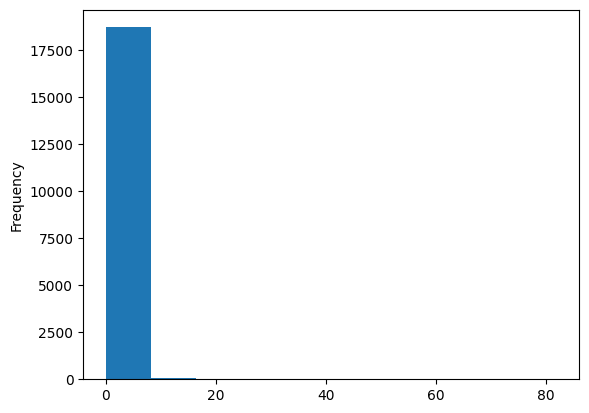

In [ ]:
resultado['MULTAS_ACUMULADAS'].plot.hist()

In [ ]:
resultado['MULTAS_RECIENTES'].value_counts()

,count
MULTAS_RECIENTES,
0,18393
1,472
